# 017 — Disaggregation IMLs for MSA stripes

Choose, for each site and each intensity measure (**AvgSA(0-3 s)** and **AvgSA(0-6 s)**),
the IMLs that (a) OpenQuake disaggregates at — the flat IML grid used by nb 020/021 — and
(b) define the per-site record-selection stripes used by nb 031-036.

For every site an interpolated collapse fragility is built from the reference-structure
fragilities (nb 013) blended over design strength `Vb_coeff`. From a candidate IML grid we
pick the (up to) 4 IMLs that best bracket the body of that fragility (targeting
P[C] = 0.15 / 0.4 / 0.6 / 0.85), keeping only IMLs at or below the PSHA truncation ceiling.
The selection is compared across truncation levels (3/4/5σ) so the working σ can be
confirmed.

## Upstream / downstream

**Upstream** (all must have been run):

- `004-psha_results` → AvgSA(0-3 s) & AvgSA(0-6 s) hazard curves at 3/4/5σ
  (`cfg["proc_data"]["AvgSA_0{3,6}_hazard_curves_{3,4,5}sig"]`)
- `010_cbfs_reference_designs_ec8_gen2_and_analyses` → reference design dataset
  (`cfg["proc_data"]["dc2_scA_reference_dataset"]`) **and** its FEMA-P695 reference IDAs,
  which must have been run so `013` can convert the collapse fragilities. Launch via
  `phd_project/scripts/WP1_ground_motion_set/batch_run_analyses/ec8_gen2_reference_structures/3s/mdof/ida.py`
  (results land in each `<tag>/mdof/ida_femap695/`).
- `011-create_site_casestudies_and_analyses` → `site_designs_summary.csv`
  (`cfg["models"]["site_specific_designs_summary"]`)
- `013-convert_reference_fragilities_to_avgsa` → reference collapse fragilities in AvgSA
  (`cfg["proc_data"]["dc2_scA_reference_collapse_fc_summary"]`)

**Downstream:**

- the flat IML grids (`disagg_imls_AvgSA_0{3,6}`) feed `020-disaggregation` / `021-…`
- the per-site stripes (`AvgSA_0{3,6}_imls_for_selection`) feed record selection
  (`031`–`036`) via `setup_AvgSA0{3,6}_gm_selection.py`, and the MSA setup in `050`
- `060-site_msa_fragility_processing` checks whether the stripes written here actually
  bracket collapse, and **feeds back**: the IMLs it writes to
  `cfg["proc_data"]["AvgSA_03_additional_imls"]` are merged into the lists below when this
  notebook is re-run (section 5). That loop is one-way and terminates — 060 only ever adds
  IMLs, and section 4's own selection is unaffected by them.

> Exploratory AvgSA sanity checks and the site-MAFC estimate were moved to
> `archived/017a-disagg_imls_sanity_and_site_mafc.ipynb`.

## 0. Setup & parameters

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from scipy.stats import lognorm
from scipy.optimize import linear_sum_assignment

from phd_project.config import config

cfg = config.load_config()

In [3]:
# ----------------------------------------------------------------------------
# PARAMETERS
# ----------------------------------------------------------------------------
# Storey counts (number of storeys) handled in this notebook. Every per-structure
# dataset (designs, fragilities, selection) is keyed by these ints, so adding a new
# structure height is just a matter of extending this list (provided its upstream
# artefacts exist).
N_STOREYS = [3, 5]

# Intensity measures handled in this notebook.
IMS = ("AvgSA_03", "AvgSA_06")

# Candidate IML grid for the iml-based disaggregation, one per IM. These are a *trial*
# grid used to drive the per-site stripe selection below; the flat grid actually written
# for OpenQuake (nb 020/021) is the minimum subset of these IMLs that some site/structure
# ends up requesting (computed in section 5). Chosen by inspection so that >=4 grid points
# land on the body of every site's collapse fragility.
IMLS_AVGSA_03 = np.array([0.250, 0.270, 0.285, 0.310, 0.330, 0.360, 0.400, 0.450, 0.500, 0.550, 0.650, 0.800, 0.950, 1.150])
IMLS_AVGSA_06 = np.array([0.100, 0.130, 0.150, 0.180, 0.220, 0.280, 0.330, 0.400, 0.480, 0.550, 0.620, 0.700])
IMLS = {"AvgSA_03": IMLS_AVGSA_03, "AvgSA_06": IMLS_AVGSA_06}

# Fragility-fit conditioning: with 30 records per stripe a binomial-MLE collapse fit is
# well conditioned when the observed collapse count is within [LO, HI].
N_RECORDS = 30
LO, HI = 3, 27

# Target collapse probabilities the (up to) 4 disaggregation IMLs should bracket.
TARGET_PCS = [0.15, 0.4, 0.6, 0.85]

# PSHA truncation (epsilon) levels to compare. The hazard ceiling (max usable IML) grows
# with the truncation level; DISAGG_SIGMA is the level whose per-site selection is written
# to the output files in section 5.
TRUNC_LEVELS = (3, 4, 5)
DISAGG_SIGMA = 4

# Fine IML grid (g) used to draw the interpolated site collapse curves.
IML_GRID = np.logspace(np.log10(0.01), np.log10(3.0), 300)  # g

# Site groups for plotting (low-moderate vs high seismicity).
GROUPS = [
    (range(0, 30), "Sites 0-29  (low-moderate seismicity)"),
    (range(30, 60), "Sites 30-59  (high seismicity)"),
]

## 1. Load hazard, designs & fragilities

Everything is loaded from `config.yaml` keys. Hazard curves come from nb 004 in the flat
structure `hcs[site_id]["AvgSA"][stat] -> ndarray (n_iml, 2)` (col 0 = IML [g], col 1 =
MAFE), one file per (IM, truncation level). Reference designs come from nb 010 and carry
`Vb_coeff` as a column (no recompute); the site-specific `Vb_coeff` comes from nb 011's
summary CSV (its `site_id` is derived from the `tag`). Reference collapse fragilities in
AvgSA come from nb 013's summary CSV, whose medians are already in **g**.

In [4]:
def load_hazard(im):
    """Mean hazard curve per truncation level for one IM.

    Returns curves[level][site] -> ndarray (n_iml, 2), col 0 = IML [g], col 1 = MAFE.
    All six nb-004 pickles share the flat hcs[site]["AvgSA"][stat] structure.
    """
    curves = {}
    for sig, level in (("3sig", 3), ("4sig", 4), ("5sig", 5)):
        with open(cfg["proc_data"][f"{im}_hazard_curves_{sig}"], "rb") as f:
            raw = pickle.load(f)
        curves[level] = {site: raw[site]["AvgSA"]["mean"] for site in sorted(raw)}
    return curves


hazard = {im: load_hazard(im) for im in IMS}
sites = sorted(hazard["AvgSA_03"][3])
print(f"loaded hazard for {len(sites)} sites, IMs {list(hazard)}, truncation levels {TRUNC_LEVELS}")

loaded hazard for 60 sites, IMs ['AvgSA_03', 'AvgSA_06'], truncation levels (3, 4, 5)


In [5]:
# Reference (site-independent) designs from nb 010, keyed by storey count. `name` and
# `Vb_coeff` are plain columns; keep only the structures whose height is in N_STOREYS.
reference_designs_all = pd.read_pickle(cfg["proc_data"]["dc2_scA_reference_dataset"])
reference_designs = {
    n: reference_designs_all[reference_designs_all["name"].str.startswith(f"{n}s_")].copy()
    for n in N_STOREYS
}

# Site-specific designs from nb 011, keyed by storey count. The CSV has no explicit site_id
# column, so derive the integer site id from the tag (e.g. "3s_cbf_dc2_site7" -> 7). We keep
# both the per-site design strength (`site_vb[n]`) and the full structure tag (`site_tags[n]`,
# used as the per-structure key when the stripes are written in section 5).
sitespec_designs = pd.read_csv(cfg["models"]["site_specific_designs_summary"])
sitespec_designs["n_storeys"] = sitespec_designs["tag"].str.extract(r"^(\d+)s_").astype(int)
sitespec_designs["site_id"] = sitespec_designs["tag"].str.split("site").str[-1].astype(int)
site_vb = {}
site_tags = {}
for n in N_STOREYS:
    sub = sitespec_designs[sitespec_designs["n_storeys"] == n]
    site_vb[n] = sub.set_index("site_id")["Vb_coeff"].sort_index()
    site_tags[n] = sub.set_index("site_id")["tag"].sort_index().to_dict()

# Reference collapse fragilities in AvgSA (nb 013). Two-level columns (IM -> median/dispersion);
# medians are already in g. Rows for every storey count share this one file (3s_… and 5s_…).
fc_summary = pd.read_csv(
    cfg["proc_data"]["dc2_scA_reference_collapse_fc_summary"], header=[0, 1], index_col=0
)
fc_summary

IM                    SA             AvgSA_03             AvgSA_06           
parameter         median dispersion    median dispersion    median dispersion
structure                                                                    
5s_dc2_scA_13   0.591873   0.343921  0.340030   0.184468  0.153762   0.237055
3s_dc2_scA_13   0.985487   0.406044  0.393142   0.216237  0.177779   0.254886
3s_dc2_scA_20   0.985487   0.406044  0.393142   0.216237  0.177779   0.254886
5s_dc2_scA_30   0.591873   0.343921  0.340030   0.184468  0.153762   0.237055
5s_dc2_scA_20   0.591873   0.343921  0.340030   0.184468  0.153762   0.237055
3s_dc2_scA_30   0.941296   0.421550  0.356276   0.180760  0.161108   0.278448
5s_dc2_scA_40   0.823168   0.306165  0.402143   0.171969  0.181849   0.260162
5s_dc2_scA_50   0.944759   0.304005  0.448493   0.180806  0.202809   0.298122
3s_dc2_scA_40   1.442773   0.536756  0.466230   0.190812  0.210830   0.327330
5s_dc2_scA_60   0.911602   0.363392  0.416281   0.224820  0.188243   0.316885
3s_dc2_scA_50   1.325881   0.527436  0.419701   0.175810  0.189789   0.327218
3s_dc2_scA_60   1.394596   0.525751  0.433242   0.177688  0.195912   0.330271
5s_dc2_scA_70   1.300693   0.351681  0.510636   0.225039  0.230910   0.356164
5s_dc2_scA_100  1.763872   0.346139  0.611886   0.209767  0.276696   0.357258
3s_dc2_scA_70   1.944080   0.396273  0.587380   0.225877  0.265614   0.388994
5s_dc2_scA_120  2.276292   0.457366  0.736444   0.213866  0.333021   0.381133
3s_dc2_scA_100  2.625250   0.332585  0.767048   0.263936  0.346860   0.417027
3s_dc2_scA_120  3.172556   0.346549  0.931035   0.283062  0.421015   0.425240

## 2. Reference collapse fragilities

For each IM assemble the reference collapse ladder — design strength `Vb_coeff` (from the
nb 010 dataset) joined to the AvgSA collapse fragility (median [g] + lognormal dispersion
from nb 013) — sorted ascending in `Vb_coeff` so it can be interpolated over strength.

In [6]:
vb_ref_lookup = {n: reference_designs[n].set_index("name")["Vb_coeff"] for n in N_STOREYS}


def build_refs(im, n):
    """Reference collapse ladder for one IM and storey count, sorted ascending in Vb_coeff."""
    names = [name for name in fc_summary.index if name.startswith(f"{n}s_")]
    refs = pd.DataFrame(
        [
            {
                "name": name,
                "Vb_coeff": float(vb_ref_lookup[n][name]),
                "median": float(fc_summary.loc[name, (im, "median")]),        # g
                "dispersion": float(fc_summary.loc[name, (im, "dispersion")]),
            }
            for name in names
        ]
    ).sort_values("Vb_coeff", ignore_index=True)
    assert refs["Vb_coeff"].is_monotonic_increasing
    return refs


# refs_by_im[n][im] -> reference collapse ladder DataFrame
refs_by_im = {n: {im: build_refs(im, n) for im in IMS} for n in N_STOREYS}
refs_by_im[N_STOREYS[0]]["AvgSA_03"]

,name,Vb_coeff,median,dispersion
0,3s_dc2_scA_13,0.026098,0.393142,0.216237
1,3s_dc2_scA_20,0.027234,0.393142,0.216237
2,3s_dc2_scA_30,0.043757,0.356276,0.180760
3,3s_dc2_scA_40,0.086012,0.466230,0.190812
4,3s_dc2_scA_50,0.114445,0.419701,0.175810
5,3s_dc2_scA_60,0.140632,0.433242,0.177688
6,3s_dc2_scA_70,0.257673,0.587380,0.225877
7,3s_dc2_scA_100,0.416667,0.767048,0.263936
8,3s_dc2_scA_120,0.500000,0.931035,0.283062


Note the fragilities are **not** perfectly monotonic in `Vb_coeff`

## 3. Interpolated site-specific collapse fragilities

Each site's collapse curve is built by blending the reference curves over design strength
(`Vb_coeff`) and evaluating on the fine IML grid — the same interpolation the stripe
selection uses. The collapse side is independent of the hazard truncation level, so it is
computed once per IM.

The plots show the interpolated site collapse curves (shaded band = the usable
binomial-fitting window) and the site hazard curves at all three truncation levels, with
the P[C] = 10/50/80 % IML windows overlaid. An `x` marks the truncation ceiling of any
hazard curve clipped by its σ level — those points cannot be disaggregated.

In [7]:
def make_site_pc_curve(refs):
    """P[C] over IML_GRID for a site of a given strength (interp over the reference ladder)."""
    pc_grid_ref = lognorm.cdf(
        IML_GRID[:, None],                         # g (fragility medians already in g)
        refs["dispersion"].to_numpy()[None, :],
        scale=refs["median"].to_numpy()[None, :],
    )  # (n_grid, n_refs)
    vb_ref = refs["Vb_coeff"].to_numpy()

    def site_pc_curve(vb_coeff):
        return np.array([np.interp(vb_coeff, vb_ref, row) for row in pc_grid_ref])

    return site_pc_curve


# site_pc_curve_by_im[n][im](vb) -> P[C] curve; site_fcs[n][im][site] -> P[C] over IML_GRID
site_pc_curve_by_im = {
    n: {im: make_site_pc_curve(refs_by_im[n][im]) for im in IMS} for n in N_STOREYS
}
site_fcs = {
    n: {im: {site: site_pc_curve_by_im[n][im](site_vb[n][site]) for site in sites} for im in IMS}
    for n in N_STOREYS
}

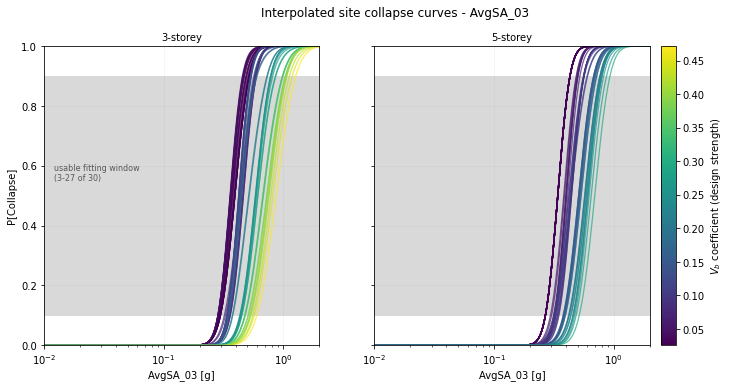

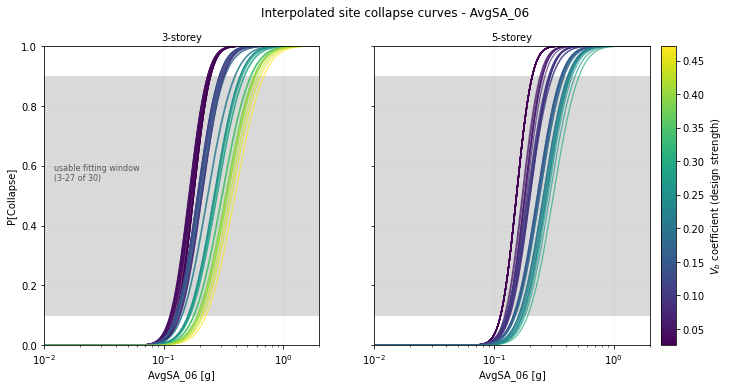

In [8]:
CMAP = plt.get_cmap("viridis")  # sequential: Vb_coeff is a magnitude
# Shared colour scale across every storey count so the axes are directly comparable.
_all_vb = pd.concat([site_vb[n] for n in N_STOREYS])
NORM = Normalize(vmin=_all_vb.min(), vmax=_all_vb.max())


def plot_site_collapse_curves(im):
    """One figure per IM; one axis per storey count, each showing all sites (both
    seismicity groups together) coloured by design strength."""
    fig, axes = plt.subplots(
        1, len(N_STOREYS), figsize=(6.5 * len(N_STOREYS), 5.5), sharey=True, sharex=True,
        squeeze=False,
    )
    for ax, n in zip(axes[0], N_STOREYS):
        ax.axhspan(LO / N_RECORDS, HI / N_RECORDS, color="0.85", zorder=0)
        for site in sites:
            ax.plot(IML_GRID, site_fcs[n][im][site], color=CMAP(NORM(site_vb[n][site])), lw=1.3, alpha=0.7)
        ax.set_xscale("log")
        ax.set_xlim(0.01, 2.0)
        ax.set_ylim(0, 1)
        ax.set_xlabel(f"{im} [g]")
        ax.set_title(f"{n}-storey", fontsize=10)
        ax.grid(alpha=0.25, lw=0.5)
    axes[0, 0].set_ylabel("P[Collapse]")
    axes[0, 0].text(0.012, 0.55, f"usable fitting window\n({LO}-{HI} of {N_RECORDS})", fontsize=8, color="0.35")
    cbar = fig.colorbar(ScalarMappable(norm=NORM, cmap=CMAP), ax=axes, pad=0.015)
    cbar.set_label("$V_b$ coefficient (design strength)")
    fig.suptitle(f"Interpolated site collapse curves - {im}", fontsize=12)
    plt.show()


for im in IMS:
    plot_site_collapse_curves(im)

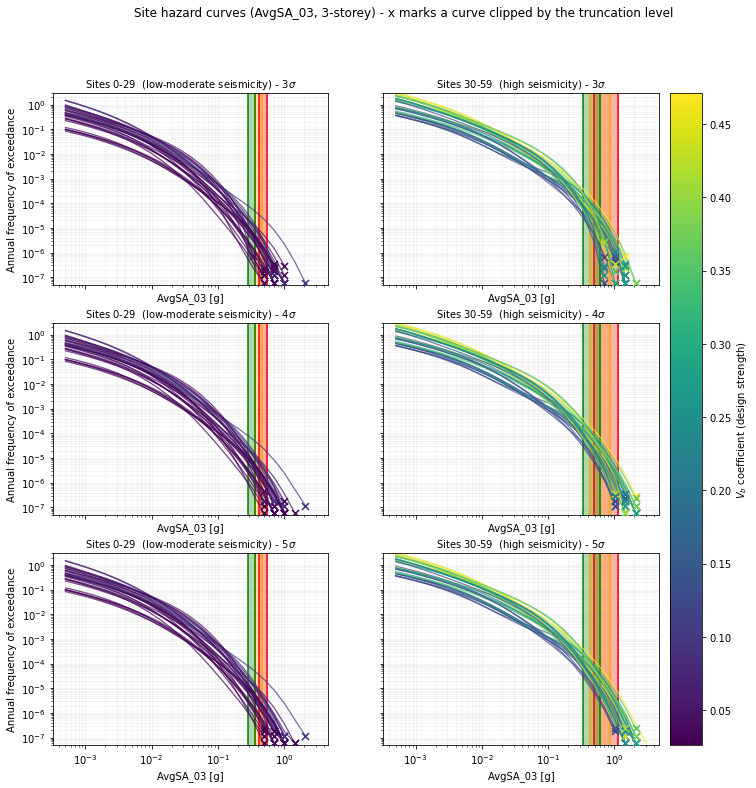

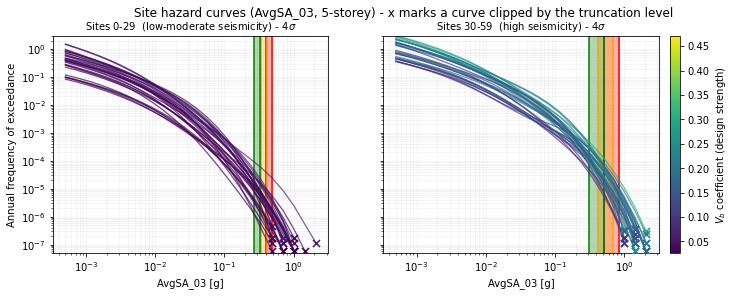

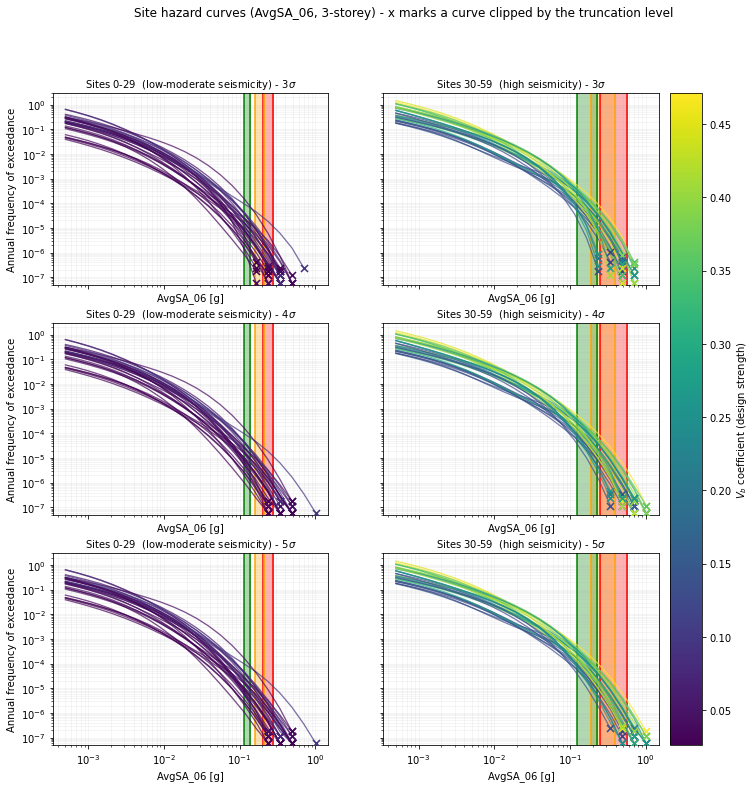

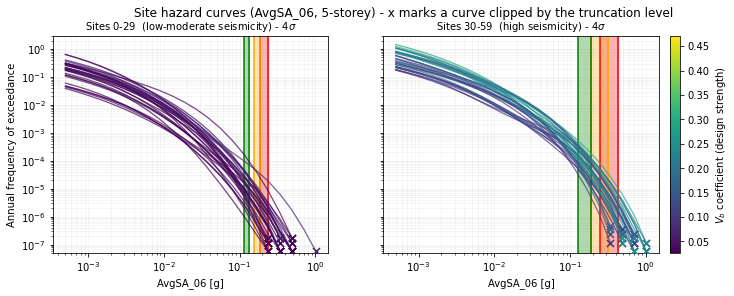

In [9]:
def pc_iml_bounds(im, n, site_range, p):
    """[min, max] IML (g) at which P[C] = p across the sites in a group (storey n)."""
    vals = [np.interp(p, site_fcs[n][im][s], IML_GRID) for s in site_range]
    return [min(vals), max(vals)]


def plot_hazard_with_windows(im, n, sigmas=TRUNC_LEVELS):
    """Site hazard curves at the given truncation level(s) with the P[C] = 10/50/80% IML
    windows (for storey count n) overlaid. Hazard is storey-independent; only the fragility
    windows and site colours change with n."""
    sigmas = list(sigmas)
    fig, axes = plt.subplots(len(sigmas), 2, figsize=(13, 4 * len(sigmas)),
                             sharey=True, sharex=True, squeeze=False)
    y1, y2 = 3e-8, 4
    for ii, level in enumerate(sigmas):
        for jj, (site_range, title) in enumerate(GROUPS):
            ax = axes[ii, jj]
            for p, colour in zip((0.8, 0.5, 0.1), ("r", "orange", "g")):
                lo, hi = pc_iml_bounds(im, n, site_range, p)
                ax.fill_betweenx([y1, y2], lo, hi, color=colour, alpha=0.3)
                ax.vlines([lo, hi], y1, y2, color=colour)
            for site in site_range:
                hc = hazard[im][level][site]
                iml, mafe = hc[:, 0], hc[:, 1]
                pos = mafe > 0  # log axis: drop the non-positive tail
                ax.plot(iml[pos], mafe[pos], color=CMAP(NORM(site_vb[n][site])), lw=1.3, alpha=0.7)
                if not pos.all():  # curve clipped by the truncation level -> flag last point
                    last = np.flatnonzero(pos)[-1]
                    ax.plot(iml[last], mafe[last], ls="none", marker="x", ms=7,
                            mec=CMAP(NORM(site_vb[n][site])), mew=1.6, zorder=3)
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlabel(f"{im} [g]")
            ax.set_title(rf"{title} - {level}$\sigma$", fontsize=10)
            ax.grid(alpha=0.25, which="both", lw=0.5)
    for ax in axes[:, 0]:
        ax.set_ylabel("Annual frequency of exceedance")
        ax.set_ylim(5e-8, 3)
    cbar = fig.colorbar(ScalarMappable(norm=NORM, cmap=CMAP), ax=axes, pad=0.015)
    cbar.set_label("$V_b$ coefficient (design strength)")
    fig.suptitle(f"Site hazard curves ({im}, {n}-storey) - x marks a curve clipped by the truncation level", fontsize=12)
    plt.show()


# The first storey count keeps the full 3/4/5 sigma comparison (this is what justifies
# DISAGG_SIGMA); every other storey count reuses that conclusion and is shown at DISAGG_SIGMA only.
for im in IMS:
    for i, n in enumerate(N_STOREYS):
        plot_hazard_with_windows(im, n, sigmas=TRUNC_LEVELS if i == 0 else (DISAGG_SIGMA,))

## 4. Select disaggregation IMLs (compared across truncation levels)

For each site the selection runs in three steps: (1) find the **ideal** match of the target
P[C]s over the full grid (the IMLs we would pick with unlimited hazard); (2) find the
**considerable** IMLs — those grid points at or below the hazard ceiling (the largest IML
with positive MAFE) for that truncation level; (3) run the Hungarian match **again over only
the considerable IMLs** to get the **selected** set. Re-matching over the reachable IMLs
(rather than matching over the full grid and then discarding out-of-reach points) ensures a
usable IML is never skipped just because a lower ideal match was truncated away.

Because the ceiling grows with σ, the selection is repeated for σ = 3/4/5 and compared: the
table reports, per (IM, σ), how many sites keep all 4 IMLs and which fall short (a site is
short only when fewer than 4 grid IMLs are reachable). Use it to confirm `DISAGG_SIGMA`
before writing the outputs in section 5. The example plots show the ideal (red) vs selected
(green) IMLs against each site's interpolated fragility.

In [10]:
def find_closest_unique_matches(targets, options):
    """Closest unique option per target via the Hungarian algorithm (min total |diff|).

    On a rectangular cost matrix scipy returns min(n_targets, n_options) matches, so with
    fewer options than targets every option is used once and the extra targets go unmatched.
    """
    t = np.asarray(targets)[:, None]
    o = np.asarray(options)[None, :]
    _, col_ind = linear_sum_assignment(np.abs(t - o))
    return [options[c] for c in col_ind], col_ind


def max_usable_iml(hc):
    """Largest IML with strictly positive MAFE (the truncation ceiling)."""
    nonpos = np.where(hc[:, 1] <= 0.0)[0]
    return hc[nonpos[0] - 1, 0] if len(nonpos) else hc[-1, 0]


def select_imls(im, n, sigma):
    """Per-site IML selection for one IM, storey count and truncation level.

    Three steps: (1) the *ideal* match of TARGET_PCS over the whole grid (what we would pick
    with unlimited hazard); (2) the *considerable* IMLs = grid points at or below the hazard
    ceiling at this sigma; (3) the *selected* IMLs = the match run again over only the
    considerable IMLs. Matching over the reachable set (rather than matching over the full
    grid and then dropping out-of-reach points) means a usable IML is never skipped just
    because a lower ideal match was truncated away.

    Returns {site: {ideal_imls, iml_max, selected_imls, n_good}}, IMLs ascending.
    """
    grid = IMLS[im]
    out = {}
    for site in sites:
        pcs = np.interp(grid, IML_GRID, site_fcs[n][im][site])   # P[C] at each grid IML

        # 1. ideal: best matches over the full grid (reference only)
        _, ideal_idxs = find_closest_unique_matches(TARGET_PCS, pcs)
        ideal_imls = grid[np.sort(ideal_idxs)]

        # 2. considerable: grid IMLs at/below the truncation ceiling
        iml_max = max_usable_iml(hazard[im][sigma][site])
        mask = grid <= iml_max

        # 3. selected: re-match over only the considerable IMLs
        if mask.any():
            _, sel_idxs = find_closest_unique_matches(TARGET_PCS, pcs[mask])
            selected = np.sort(grid[mask][sel_idxs])
        else:
            selected = np.array([])

        out[site] = {
            "ideal_imls": ideal_imls,
            "iml_max": iml_max,
            "selected_imls": selected,
            "n_good": int(len(selected)),
        }
    return out


# selection[n][im][sigma][site] -> {ideal_imls, iml_max, selected_imls, n_good}
selection = {
    n: {im: {sigma: select_imls(im, n, sigma) for sigma in TRUNC_LEVELS} for im in IMS}
    for n in N_STOREYS
}

In [11]:
# Comparison across truncation levels: how many of the (up to 4) suitable IMLs survive the
# hazard ceiling at each sigma, per storey count and IM. Use this to pick DISAGG_SIGMA.
rows = []
for n in N_STOREYS:
    for im in IMS:
        for sigma in TRUNC_LEVELS:
            sel = selection[n][im][sigma]
            n_good = np.array([sel[s]["n_good"] for s in sites])
            rows.append({
                "n_storeys": n,
                "IM": im,
                "sigma": sigma,
                "sites_with_4": int((n_good == 4).sum()),
                "sites_with_3": int((n_good == 3).sum()),
                "sites_with_<=2": int((n_good <= 2).sum()),
                "flagged_<4": [s for s in sites if sel[s]["n_good"] < 4],
            })
comparison = pd.DataFrame(rows)
comparison

,n_storeys,IM,sigma,sites_with_4,sites_with_3,sites_with_<=2,flagged_<4
0,3,AvgSA_03,3,60,0,0,[]
1,3,AvgSA_03,4,60,0,0,[]
2,3,AvgSA_03,5,60,0,0,[]
3,3,AvgSA_06,3,56,4,0,"[8, 19, 22, 27]"
4,3,AvgSA_06,4,60,0,0,[]
5,3,AvgSA_06,5,60,0,0,[]
6,5,AvgSA_03,3,60,0,0,[]
7,5,AvgSA_03,4,60,0,0,[]
8,5,AvgSA_03,5,60,0,0,[]
9,5,AvgSA_06,3,56,4,0,"[8, 19, 22, 27]"


AvgSA_03 3-storey site with fewest usable IMLs at 4 sigma: site 0 (4 IMLs)
AvgSA_03 5-storey site with fewest usable IMLs at 4 sigma: site 0 (4 IMLs)


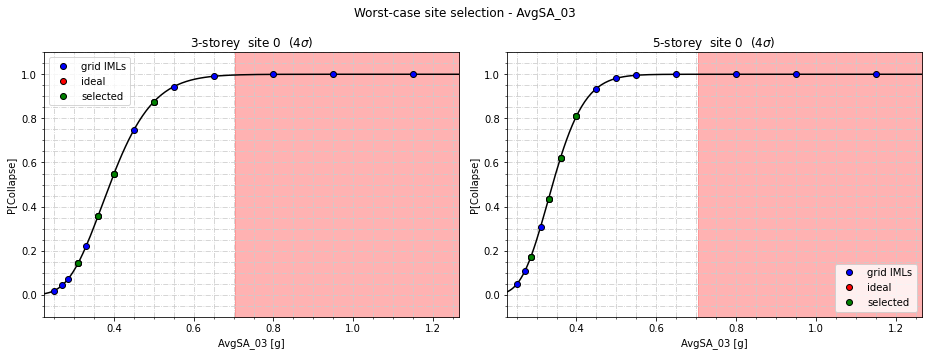

In [12]:
def plot_site_selection(im, n, site, sigma=DISAGG_SIGMA, ax=None):
    """Interpolated fragility for one site (storey n) with its grid / ideal / selected IMLs
    marked. Draws on `ax` if given, otherwise creates its own figure."""
    sel = selection[n][im][sigma][site]
    grid = IMLS[im]
    fc = site_fcs[n][im][site]

    def pc(x):
        return np.interp(x, IML_GRID, fc)

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots()
    ax.plot(IML_GRID, fc, color="k")
    ax.plot(grid, pc(grid), ls="", marker="o", mfc="b", mec="k", label="grid IMLs")
    ax.plot(sel["ideal_imls"], pc(sel["ideal_imls"]), ls="", marker="o", mfc="r", mec="k", label="ideal")
    ax.plot(sel["selected_imls"], pc(sel["selected_imls"]), ls="", marker="o", mfc="g", mec="k", label="selected")
    ax.fill_betweenx([-0.1, 1.1], sel["iml_max"], grid[-1] * 1.1, color="r", alpha=0.3)
    ax.set_xlim(grid[0] * 0.9, grid[-1] * 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlabel(f"{im} [g]")
    ax.set_ylabel("P[Collapse]")
    ax.set_title(rf"{n}-storey  site {site}  ({sigma}$\sigma$)")
    ax.grid(which="both", ls="-.", color="0.8")
    ax.minorticks_on()
    ax.legend()
    if own_fig:
        plt.show()


def plot_worst_examples(im, sigma=DISAGG_SIGMA):
    """One figure per IM; one axis per storey count, each showing that storey's site with the
    fewest usable IMLs at `sigma`."""
    fig, axes = plt.subplots(1, len(N_STOREYS), figsize=(6.5 * len(N_STOREYS), 5), squeeze=False)
    for ax, n in zip(axes[0], N_STOREYS):
        worst = min(sites, key=lambda s: selection[n][im][sigma][s]["n_good"])
        print(f"{im} {n}-storey site with fewest usable IMLs at {sigma} sigma: site {worst} "
              f"({selection[n][im][sigma][worst]['n_good']} IMLs)")
        plot_site_selection(im, n, worst, sigma=sigma, ax=ax)
    fig.suptitle(f"Worst-case site selection - {im}", fontsize=12)
    fig.tight_layout()
    plt.show()


plot_worst_examples("AvgSA_03")

AvgSA_06 3-storey site with fewest usable IMLs at 4 sigma: site 0 (4 IMLs)
AvgSA_06 5-storey site with fewest usable IMLs at 4 sigma: site 0 (4 IMLs)


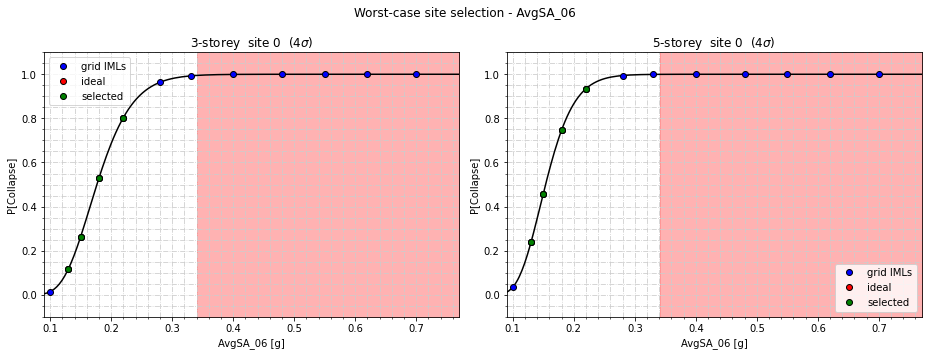

In [13]:
plot_worst_examples("AvgSA_06")

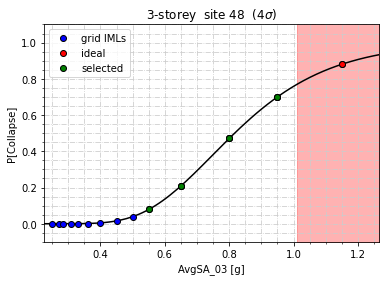

In [14]:
# --- Manual site check: edit the parameters below to inspect any (storey, site) by hand ---
IM_CHECK = "AvgSA_03"
N_STOREYS_CHECK = 3  # one of N_STOREYS
SITE_CHECK = 48
SIGMA_CHECK = 4  # one of TRUNC_LEVELS (3, 4, 5)
plot_site_selection(IM_CHECK, N_STOREYS_CHECK, SITE_CHECK, sigma=SIGMA_CHECK)

Some examples of interesting sites to look at are 22, 38, 49, 48 (AvgSA_03)

## 5. Write outputs

Two artefacts per IM, at the chosen truncation level `DISAGG_SIGMA`:

1. **Per-site record-selection stripes** → `cfg["proc_data"]["AvgSA_0{3,6}_imls_for_selection"]`,
   JSON `{site_id: {structure_tag: {...}, ..., "union": [imls]}}`. Each structure entry keeps
   its three kinds of IML apart, because notebook 050 has to tell them apart when it decides
   what to actually run:

   | field | content |
   | --- | --- |
   | `stripes` | the (≤4) suitable IMLs section 4 selected |
   | `reserves` | `[one grid step below, one above]`; either is `null` where the grid ran out or the neighbour exceeds the hazard ceiling |
   | `additional` | remediation IMLs merged back in from notebook 060, `[]` until 060 has run |

   The `"union"` list is the sorted set of every non-`null` IML requested by any structure at
   that site — the set of stripes actually run there — and is the only part of the file the
   record-selection setup scripts consume.

2. **Flat disaggregation IML grid** → `cfg["proc_data"]["disagg_imls_AvgSA_0{3,6}"]`
   (`np.savetxt`), the IMLs OpenQuake disaggregates at (nb 020/021). This is **not** the full
   trial grid: it is the minimum subset of trial IMLs that appears in some site's `"union"`, so
   no IML is disaggregated that no structure/site requests — plus any `additional` IMLs, which
   are picked off the *fitted* fragilities and so do not sit on the trial grid at all.

Nothing here is cached: every run recomputes and overwrites both artefacts, so re-running
after 060 has produced new IMLs is the intended way to fold them in.

In [15]:
def load_additional_imls(im):
    """Remediation IMLs from notebook 060, as {site_str: {structure_tag: {imls}}}.

    Section 4 picks the four stripe IMLs by matching TARGET_PCS against the *interpolated
    reference* fragilities - the best guess available before anything has been run. Once the
    real MSA came back, notebook 060 found that guess had not spread the stripes widely
    enough: for most structures the empirical curve never dropped below P[C] 0.2 or rose
    above 0.8, so the binomial MLE had nothing to anchor on at one or both tails. The IMLs in
    this file are 060's remedy - extra stripes picked off each structure's *fitted* fragility,
    so they land in the tails the first pass missed. They are merged in here because this
    notebook is what defines the disaggregation grid and the per-site record-selection lists.

    Stored as {"3": [[site, iml], ...], "5": [...]}, one entry per IML needed. Absent on a
    first run - 060 cannot run until this notebook has - which is not an error.
    """
    fp = cfg["proc_data"].get(f"{im}_additional_imls")
    if fp is None or not Path(fp).is_file():
        reason = "no config key" if fp is None else f"{Path(fp).name} not written yet"
        print(f"  no additional IMLs for {im} ({reason})")
        return {}

    with open(fp) as f:
        raw = json.load(f)
    extra = {}
    for n, pairs in raw.items():
        for site, iml in pairs:
            tag = site_tags[int(n)][site]
            extra.setdefault(str(site), {}).setdefault(tag, set()).add(round(float(iml), 4))

    n_imls = sum(len(v) for tags in extra.values() for v in tags.values())
    print(f"  merging {n_imls} additional IMLs for {im} from {Path(fp).name}")
    return extra


def build_structure_entry(im, n, sigma, site, additional=()):
    """Record-selection entry for one structure (storey n) at a site.

    {"stripes":    the IMLs section 4 selected,
     "reserves":   [one grid step below, one above], either None where the grid ran out or
                   the neighbour sat above the site's hazard ceiling,
     "additional": remediation IMLs merged in from notebook 060, empty until 060 has run}

    The three are kept apart rather than flattened into one list because notebook 050 has to
    tell them apart: it runs the stripes and every additional IML, but only those reserves
    notebook 060 flagged as worth running.
    """
    grid = list(IMLS[im])
    sel = selection[n][im][sigma][site]
    chosen = [float(x) for x in sel["selected_imls"]]
    if not chosen:
        # nothing usable (does not occur for the current grids)
        return {"stripes": [], "reserves": [None, None], "additional": []}

    lo_i = grid.index(min(chosen))
    hi_i = grid.index(max(chosen))
    lower = grid[lo_i - 1] if lo_i - 1 >= 0 else None
    upper = grid[hi_i + 1] if (hi_i + 1 < len(grid) and grid[hi_i + 1] <= sel["iml_max"]) else None

    rnd = lambda x: round(float(x), 4) if x is not None else None
    stripes = [rnd(x) for x in chosen]          # already ascending
    reserves = [rnd(lower), rnd(upper)]
    known = set(stripes) | {x for x in reserves if x is not None}
    return {"stripes": stripes,
            "reserves": reserves,
            "additional": sorted(set(additional) - known)}


def entry_imls(entry):
    """Every non-null IML in one structure entry, across all three fields."""
    return [x for field in ("stripes", "reserves", "additional")
            for x in entry[field] if x is not None]


def build_per_site_imls(im, sigma):
    """Per-site record-selection stripes as {site: {structure_tag: entry, ..., "union": [imls]}}.

    See build_structure_entry for the per-structure fields. "union" is the sorted set of every
    non-null IML any structure at the site requests - the set of stripes actually run there -
    and is the only part of this file record selection (nb 031-036) reads.
    """
    additional = load_additional_imls(im)
    result = {}
    for site in sites:
        entry = {}
        union = set()
        for n in N_STOREYS:
            tag = site_tags[n][site]
            structure = build_structure_entry(
                im, n, sigma, site, additional.get(str(site), {}).get(tag, ()))
            entry[tag] = structure
            union.update(entry_imls(structure))
        entry["union"] = sorted(union)
        result[str(site)] = entry
    return result


def used_imls_from_per_site(per_site):
    """Minimum flat IML grid: every distinct IML that appears in any site's union stripe."""
    used = set()
    for entry in per_site.values():
        used.update(entry["union"])
    return np.array(sorted(used))


def write_outputs(sigma=DISAGG_SIGMA):
    for im in IMS:
        # per-site record-selection stripes (nb 031-036), per structure + a union list
        per_site = build_per_site_imls(im, sigma)
        sel_fp = cfg["proc_data"][f"{im}_imls_for_selection"]
        with open(sel_fp, "w") as f:
            json.dump(per_site, f, indent=4)
        structures = [s for entry in per_site.values()
                      for tag, s in entry.items() if tag != "union"]
        n_null = sum(1 for s in structures if None in s["reserves"])
        n_extra = sum(len(s["additional"]) for s in structures)
        print(f"wrote {sel_fp.name}  ({len(per_site)} sites, "
              f"{n_null} structures with a null reserve, "
              f"{n_extra} additional IMLs merged)")

        # flat disaggregation IML grid (nb 020/021): the minimum subset of the trial grid that
        # some site/structure actually requests (union across all sites), not the whole grid -
        # plus any additional IMLs, which come off the fitted fragilities and so are off-grid.
        used = used_imls_from_per_site(per_site)
        grid_fp = cfg["proc_data"][f"disagg_imls_{im}"]
        np.savetxt(grid_fp, used, delimiter=",")
        n_trial = sum(1 for x in used if np.any(np.isclose(IMLS[im], x)))
        print(f"wrote {grid_fp.name}  ({len(used)} IMLs to disaggregate: {n_trial} of "
              f"{len(IMLS[im])} trial IMLs + {len(used) - n_trial} additional)")


write_outputs(DISAGG_SIGMA)

  merging 97 additional IMLs for AvgSA_03 from additional_imls_for_disagg_AvgSA_03.json
wrote imls_for_selection_AvgSA_03.json  (60 sites, 9 structures with a null reserve, 97 additional IMLs merged)
wrote AvgSA_03_imls_for_disaggregation.csv  (27 IMLs to disaggregate: 13 of 14 trial IMLs + 14 additional)
  no additional IMLs for AvgSA_06 (no config key)
wrote imls_for_selection_AvgSA_06.json  (60 sites, 25 structures with a null reserve, 0 additional IMLs merged)
wrote AvgSA_06_imls_for_disaggregation.csv  (12 IMLs to disaggregate: 12 of 12 trial IMLs + 0 additional)


## 6. Summary
4 $\sigma$ offers the best balance between the a sensible truncation limit and allowing strong enough hazard to select stripes that are useful for fragility curve fitting. For this reason I will continue the rest of this work using a 4 $\sigma$ hazard and I will perform the disaggregation at the 4 $\sigma$ level. 3 $\sigma$ and 5 $\sigma$ won't play any further role.